## 지난주 개념 복습!
아래 마크다운을 풀고, 지난주 예습과제를 통해 공부한 Vision Transformer의 특징과 다른 모델들과의 차이점을 간략히 설명해주세요.

- 다른 모델들은 해당 모델이 갖는 구조와 매개변수들이 특정 데이터에 적합한 귀납적 편향을 가지지만, vision transformer 모델은 입력 데이터의 다양한 쿼리, 키, 값의 임베딩 형태로 일반화된 관계를 학습하기 때문에 귀납적 편향이 거의 없다
- 이미지를 작은 패치들로 나누고 모든 이미지 패치를 학습에 이용한다.

## 파이토치로 구현한 Vision Transformer
이번 복습과제에서는 카사바 잎 질병 데이터셋으로 vision transformer를 학습시키겠습니다.
- 첨부된 드라이브에서 필요한 파일들을 다운받을 수 있습니다.

In [1]:
!wget https://www.python.org/ftp/python/3.10.14/Python-3.10.14.tgz
!tar xvfz Python-3.10.14.tgz
!Python-3.10.14/configure
!make
!sudo make install

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
Listing '/usr/local/lib/python3.10/site-packages/sympy/parsing/autolev/_antlr'...
Compiling '/usr/local/lib/python3.10/site-packages/sympy/parsing/autolev/__init__.py'...
Compiling '/usr/local/lib/python3.10/site-packages/sympy/parsing/autolev/_antlr/__init__.py'...
Compiling '/usr/local/lib/python3.10/site-packages/sympy/parsing/autolev/_antlr/autolevlexer.py'...
Compiling '/usr/local/lib/python3.10/site-packages/sympy/parsing/autolev/_antlr/autolevlistener.py'...
Compiling '/usr/local/lib/python3.10/site-packages/sympy/parsing/autolev/_antlr/autolevparser.py'...
Compiling '/usr/local/lib/python3.10/site-packages/sympy/parsing/autolev/_build_autolev_antlr.py'...
Listing '/usr/local/lib/python3.10/site-packages/sympy/parsing/autolev/test-examples'...
Compiling '/usr/local/lib/python3.10/site-packages/sympy/parsing/autolev/_listener_autolev_antlr.py'...
Listing '/usr/local/lib/python3.10/site-packages/sympy/parsing/autolev/test-examples/pydy-example-r

In [2]:
!curl https://raw.githubusercontent.com/pytorch/xla/master/contrib/scripts/env-setup.py -o pytorch-xla-env-setup.py
!python pytorch-xla-env-setup.py --version 1.7
!pip install timm
!pip install torch_xla

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    14  100    14    0     0     89      0 --:--:-- --:--:-- --:--:--    89
  File "/content/pytorch-xla-env-setup.py", line 1
    404: Not Found
    ^^^
SyntaxError: illegal target for annotation


### 데이터 불러오기

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
#.zip 파일 unzip
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip /content/drive/MyDrive/Euron/train_images.zip -d /content/drive/MyDrive/Euron/train_images

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
  inflating: /content/drive/MyDrive/Euron/train_images/3952546193.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images/3952799769.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images/3953140534.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images/3953222407.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images/3953247024.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images/3953327881.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images/3953331047.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images/3953514366.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images/3953530273.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images/3953560426.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images/3953648207.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images/3953857113.jpg  
  inflating: /content/drive/MyDrive/Euron/train_images/3953901317.jpg  
  inflating: /content/drive/

In [19]:
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip /content/drive/MyDrive/Euron/jx_vit_base_p16_224-80ecf9dd.pth.zip -d /content/drive/MyDrive/Euron/

Archive:  /content/drive/MyDrive/Euron/jx_vit_base_p16_224-80ecf9dd.pth.zip
replace /content/drive/MyDrive/Euron/jx_vit_base_p16_224-80ecf9dd.pth? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
error:  cannot delete old /content/drive/MyDrive/Euron/jx_vit_base_p16_224-80ecf9dd.pth
        Is a directory


In [23]:
#파일 경로
DATA_PATH = "/content/drive/MyDrive/Euron"
TRAIN_PATH = "/content/drive/MyDrive/Euron/train_images"
TEST_PATH = "/content/drive/MyDrive/Euron/test.jpg"
MODEL_PATH = (
    "/content/drive/MyDrive/Euron/jx_vit_base_p16_224-80ecf9dd.pth"
)

### 라이브러리

In [7]:
import sys
import subprocess

# timm이 설치된 경로를 찾습니다.
try:
    # 'pip show timm' 명령을 실행하여 설치 경로(Location)를 추출합니다.
    result = subprocess.run(['pip', 'show', 'timm'], capture_output=True, text=True, check=True)
    location_line = [line for line in result.stdout.split('\n') if line.startswith('Location:')][0]
    install_path = location_line.split(': ')[1].strip()

    # 이 경로가 sys.path에 없으면 추가합니다.
    if install_path not in sys.path:
        sys.path.append(install_path)
        print(f"✅ 설치 경로 '{install_path}'를 시스템 경로에 추가했습니다.")
    else:
        print(f"✅ 설치 경로 '{install_path}'는 이미 시스템 경로에 있습니다.")

except Exception as e:
    print(f"⚠️ pip show timm 실행 중 오류가 발생했습니다: {e}")

# 전체 시스템 경로를 확인합니다.
print("\n현재 시스템 경로:")
for path in sys.path:
    print(f"- {path}")

✅ 설치 경로 '/usr/local/lib/python3.10/site-packages'를 시스템 경로에 추가했습니다.

현재 시스템 경로:
- /content
- /env/python
- /usr/lib/python312.zip
- /usr/lib/python3.12
- /usr/lib/python3.12/lib-dynload
- 
- /usr/local/lib/python3.12/dist-packages
- /usr/lib/python3/dist-packages
- /usr/local/lib/python3.12/dist-packages/IPython/extensions
- /root/.ipython
- /usr/local/lib/python3.12/dist-packages/setuptools/_vendor
- /tmp/tmph27chdg6
- /usr/local/lib/python3.10/site-packages


In [8]:
import timm

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

import torch
import torch.nn as nn
import torchvision.transforms as transforms

import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.distributed.xla_multiprocessing as xmp
import torch_xla.distributed.parallel_loader as pl

import timm

import gc
import os
import time
import random
from datetime import datetime

from PIL import Image
from tqdm.notebook import tqdm
from sklearn import model_selection, metrics

In [11]:
os.environ["XLA_USE_BF16"] = "1"
os.environ["XLA_TENSOR_ALLOCATOR_MAXSIZE"] = "100000000"

In [12]:
def seed_everything(seed):
    """
    Seeds basic parameters for reproductibility of results

    Arguments:
        seed {int} -- Number of the seed
    """
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(1001)

### 파라미터

In [13]:
IMG_SIZE = (224,224)  #ViT에 적합한 이미지 크기로 설정해주세요.
BATCH_SIZE = 16
LR = 2e-05
GAMMA = 0.7
N_EPOCHS = 1  #모델 학습을 위해서는 더 많은 에포크가 필요하지만, 파일 크기가 큰 관계로 이번 과제에서는 전 과정을 한 번만 수행하겠습니다.

In [15]:
# pandas로 csv 파일을 읽은 뒤, 첫 5행을 출력하세요.
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  21397 non-null  object
 1   label     21397 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 334.5+ KB


<Axes: xlabel='label'>

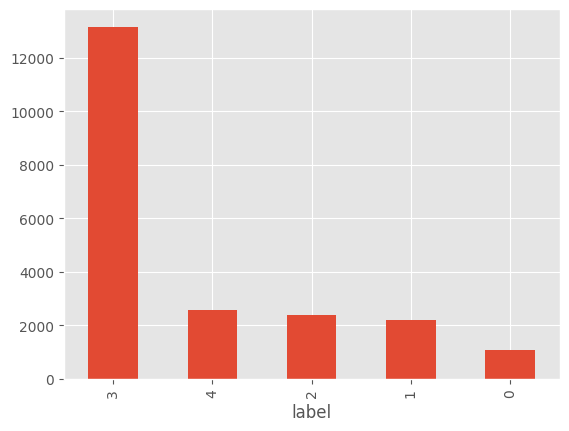

In [14]:
df.label.value_counts().plot(kind="bar")

In [16]:
# train과 test를 9:1로 나눠주세요.
# random_state은 자유롭게 지정 가능합니다.
train_df, valid_df = model_selection.train_test_split(
    df, test_size=0.1, random_state=121, stratify=df.label.values
)

In [17]:
class CassavaDataset(torch.utils.data.Dataset):

    def __init__(self, df, data_path=DATA_PATH, mode="train", transforms=None):
        super().__init__()
        self.df_data = df.values
        self.data_path = data_path
        self.transforms = transforms
        self.mode = mode
        self.data_dir = "train_images" if mode == "train" else "test_images"

    def __len__(self):
        return len(self.df_data)

    def __getitem__(self, index):
        img_name, label = self.df_data[index]
        img_path = os.path.join(self.data_path, self.data_dir, img_name)
        img = Image.open(img_path).convert("RGB")

        if self.transforms is not None:
            image = self.transforms(img)

        return image, label

In [18]:
#데이터 증강
transforms_train = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

transforms_valid = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

In [19]:
#사용 가능한 ViT 모델 목록
##우리는 이중 vit_base_patch16_224를 사용합니다!
print("Available Vision Transformer Models: ")
timm.list_models("vit*")

Available Vision Transformer Models: 


['vit_7b_patch16_dinov3',
 'vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_dinov3',
 'vit_base_patch16_dinov3_qkvb',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_plus_clip_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_224',
 'vit_base_patch16_rope_ape_224',
 'vit_base_patch16_rope_mixed_224',
 'vit_base_patch16_rope_mixed_ape_224',
 'vit_base_patch16_rope_reg1_gap_256',
 'vit_base_patch16_rpn_224',
 'vit_base_patch16_siglip_224',
 'vit_base_patch16_siglip_256',
 'vit_base_patch16_siglip_384',
 'vit_base_patch16_siglip_512',
 'vit_base_patch16_siglip_gap_224',
 'vit_base_patch16_siglip_gap_256',
 'vit_base_patch16_siglip_gap_384',
 'vit_base_patch16_siglip

### 모델 설계
- 클래스 ViTBase16의 각 줄을 설명하는 주석을 달아주세요. (최소 15개)

In [20]:
# 이 셀 안의 코드에 대해서 주석을 달아주세요.
class ViTBase16(nn.Module):
    def __init__(self, n_classes, pretrained=False):

        super(ViTBase16, self).__init__()

        self.model = timm.create_model("vit_base_patch16_224", pretrained=False) # 모델 구조만 가져오기
        if pretrained:
            self.model.load_state_dict(torch.load(MODEL_PATH)) # 모델 불러오기, 경로에서 사전 학습 매개변수 load

        self.model.head = nn.Linear(self.model.head.in_features, n_classes)

    def forward(self, x): # 순전파 함수
        x = self.model(x) # 모델 순전파 진행
        return x

    def train_one_epoch(self, train_loader, criterion, optimizer, device):
        epoch_loss = 0.0
        epoch_accuracy = 0.0

        self.model.train() # 모델 학습
        for i, (data, target) in enumerate(train_loader):
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()
            elif device.type == "xla":
                data = data.to(device, dtype=torch.float32)
                target = target.to(device, dtype=torch.int64)

            optimizer.zero_grad() # 옵티마이저 기울기 초기화
            output = self.forward(data)
            loss = criterion(output, target) # 손실 계산
            loss.backward() # 역전파 수행
            accuracy = (output.argmax(dim=1) == target).float().mean() # 예측 수행해 정답 비율 계산

            epoch_loss += loss # 누적 손실 계산
            epoch_accuracy += accuracy # 누적 정확도

            if device.type == "xla": # xla: 성능 최적화 컴파일러
                xm.optimizer_step(optimizer)
                # 20마다 배치 손실 출력
                if i % 20 == 0:
                    xm.master_print(f"\tBATCH {i+1}/{len(train_loader)} - LOSS: {loss}")

            else:
                optimizer.step() # 파라미터 갱신
        # 평균 loss, 평균 accuracy 반환
        return epoch_loss / len(train_loader), epoch_accuracy / len(train_loader)
    # 검증
    def validate_one_epoch(self, valid_loader, criterion, device):
        valid_loss = 0.0
        valid_accuracy = 0.0

        self.model.eval()
        for data, target in valid_loader:
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()
            elif device.type == "xla":
                data = data.to(device, dtype=torch.float32)
                target = target.to(device, dtype=torch.int64)

            with torch.no_grad():
                output = self.model(data)
                loss = criterion(output, target)
                accuracy = (output.argmax(dim=1) == target).float().mean()

                valid_loss += loss
                valid_accuracy += accuracy

        return valid_loss / len(valid_loader), valid_accuracy / len(valid_loader)

In [21]:
def fit_tpu(
    model, epochs, device, criterion, optimizer, train_loader, valid_loader=None
):

    valid_loss_min = np.inf

    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    for epoch in range(1, epochs + 1):
        gc.collect()
        para_train_loader = pl.ParallelLoader(train_loader, [device])

        xm.master_print(f"{'='*50}")
        xm.master_print(f"EPOCH {epoch} - TRAINING...")
        train_loss, train_acc = model.train_one_epoch(
            para_train_loader.per_device_loader(device), criterion, optimizer, device
        )
        xm.master_print(
            f"\n\t[TRAIN] EPOCH {epoch} - LOSS: {train_loss}, ACCURACY: {train_acc}\n"
        )
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        gc.collect()

        if valid_loader is not None:
            gc.collect()
            para_valid_loader = pl.ParallelLoader(valid_loader, [device])
            xm.master_print(f"EPOCH {epoch} - VALIDATING...")
            valid_loss, valid_acc = model.validate_one_epoch(
                para_valid_loader.per_device_loader(device), criterion, device
            )
            xm.master_print(f"\t[VALID] LOSS: {valid_loss}, ACCURACY: {valid_acc}\n")
            valid_losses.append(valid_loss)
            valid_accs.append(valid_acc)
            gc.collect()

            if valid_loss <= valid_loss_min and epoch != 1:
                xm.master_print(
                    "Validation loss decreased ({:.4f} --> {:.4f}).  Saving model ...".format(
                        valid_loss_min, valid_loss
                    )
                )

            valid_loss_min = valid_loss

    return {
        "train_loss": train_losses,
        "valid_losses": valid_losses,
        "train_acc": train_accs,
        "valid_acc": valid_accs,
    }

In [25]:
model = ViTBase16(n_classes=5, pretrained=True)

In [26]:
def _run():
    train_dataset = CassavaDataset(df=train_df, transforms=transforms_train) # train_df 사용
    valid_dataset = CassavaDataset(df=valid_df, transforms=transforms_valid) # valid_df 사용

    train_sampler = torch.utils.data.distributed.DistributedSampler(
        train_dataset,
        num_replicas=xm.xrt_world_size(),
        rank=xm.get_ordinal(),
        shuffle=True,
    )

    valid_sampler = torch.utils.data.distributed.DistributedSampler(
        valid_dataset,
        num_replicas=xm.xrt_world_size(),
        rank=xm.get_ordinal(),
        shuffle=False,
    )

    train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset, # train_dataset 사용
        batch_size=BATCH_SIZE, # BATCH_SIZE 사용
        sampler=train_sampler,
        drop_last=True,
        num_workers=8,
    )

    valid_loader = torch.utils.data.DataLoader(
        dataset=valid_dataset, # valid_dataset 사용
        batch_size=BATCH_SIZE, # BATCH_SIZE 사용
        sampler=valid_sampler, # valid_sampler 사용
        drop_last=True,
        num_workers=8,
    )

    criterion = nn.CrossEntropyLoss()  #cross entropy loss로 설정.
    device = xm.xla_device()
    model.to(device)

    lr = LR * xm.xrt_world_size()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    xm.master_print(f"INITIALIZING TRAINING ON {xm.xrt_world_size()} TPU CORES")
    start_time = datetime.now()
    xm.master_print(f"Start Time: {start_time}")

    logs = fit_tpu(
        model=model,
        epochs=N_EPOCHS,
        device=device,
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        valid_loader=valid_loader,
    )

    xm.master_print(f"Execution time: {datetime.now() - start_time}")

    xm.master_print("Saving Model")
    xm.save(
        model.state_dict(), f'model_5e_{datetime.now().strftime("%Y%m%d-%H%M")}.pth'
    )

In [27]:
# Training 시작
def _mp_fn(rank, flags):
    torch.set_default_tensor_type("torch.FloatTensor")
    a = _run()


# Run
FLAGS = {}
xmp.spawn(_mp_fn, args=(FLAGS,), nprocs=1, start_method="fork")

/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1264: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:434.)
  _C._set_default_tensor_type(t)


AttributeError: module 'torch_xla.core.xla_model' has no attribute 'xrt_world_size'